# Desafío 2 - Situación 1

**Validación del instrumento, reducción dimensional e identificación de tipologías**

Este notebook presenta el análisis multivariado de la Situación 1 con un formato de informe. El objetivo es validar la estructura del sub-instrumento humano, reducir la dimensionalidad de la matriz completa y construir tipologías interpretables de prompts para orientar la evaluación del modelo NLA-7B.

El desarrollo se organiza en cuatro secciones:

- **Validación de la Estructura del Instrumento**
- **Reducción de Dimensionalidad y Extracción de Características (EFA/PC)**
- **Identificación de Tipologías**
- **Caracterización e Interpretación de Perfiles**


### Preparación del entorno

Se importan las librerías requeridas para el análisis, visualización, análisis factorial confirmatorio, componentes principales y clustering.


In [1]:
# Ejecutar solo si hace falta:
# !pip install semopy factor-analyzer seaborn


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

from semopy import Model, calc_stats
from factor_analyzer.rotator import Rotator


### Funciones generales reutilizables

Se definen funciones auxiliares para mantener el notebook ordenado y evitar repetir código en tareas como carga de datos, estandarización y presentación de resultados.


In [3]:
def resolver_ruta(nombre_archivo):
    """
    Busca un archivo en el directorio actual y, si se está ejecutando en el entorno de ChatGPT,
    también en /mnt/data.
    """
    rutas_posibles = [
        Path(nombre_archivo),
        Path("/mnt/data") / nombre_archivo
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            return ruta

    raise FileNotFoundError(
        f"No se encontró el archivo {nombre_archivo}. "
        "Ubícalo en la misma carpeta del notebook o ajusta la ruta manualmente."
    )


def cargar_datos(nombre_archivo):
    """
    Carga el archivo CSV y muestra sus dimensiones.
    """
    ruta = resolver_ruta(nombre_archivo)
    df = pd.read_csv(ruta)
    print(f"Archivo cargado desde: {ruta}")
    print(f"Dimensiones del dataset: {df.shape}")
    return df


def estandarizar_dataframe(df, columnas=None):
    """
    Estandariza un DataFrame usando StandardScaler.
    Si no se indican columnas, estandariza todas las columnas.
    """
    if columnas is None:
        columnas = df.columns.tolist()

    escalador = StandardScaler()
    matriz_estandarizada = escalador.fit_transform(df[columnas])

    return pd.DataFrame(
        matriz_estandarizada,
        columns=columnas,
        index=df.index
    )


def mostrar_resumen_basico(df):
    """
    Muestra un resumen descriptivo compacto para variables numéricas.
    """
    resumen = pd.DataFrame({
        "faltantes": df.isna().sum(),
        "media": df.mean(),
        "desviacion": df.std(),
        "minimo": df.min(),
        "maximo": df.max()
    })
    display(resumen.round(3))
    return resumen


def mostrar_vista_compacta(df, filas=5, columnas=10, decimales=3):
    """
    Muestra una vista acotada para evitar salidas extensas en el informe.
    """
    columnas_mostradas = min(columnas, df.shape[1])
    display(df.iloc[:filas, :columnas_mostradas].round(decimales))

    if df.shape[1] > columnas_mostradas:
        print(
            f"Vista compacta: {filas} filas y {columnas_mostradas} "
            f"de {df.shape[1]} columnas totales."
        )


### Carga del dataset

El archivo `neuro_lingua_ai.csv` contiene 200 prompts evaluados. La columna `prompt_id` identifica cada observación y las demás columnas corresponden a variables humanas e internas del modelo.


In [4]:
df = cargar_datos("neuro_lingua_ai.csv")
mostrar_vista_compacta(df, filas=5, columnas=10)


Archivo cargado desde: neuro_lingua_ai.csv
Dimensiones del dataset: (200, 3001)
Vista compacta: 5 filas y 10 de 3001 columnas totales.


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9
0,1,-0.339,-0.287,0.729,0.861,1.186,2.184,1.427,2.025,0.993
1,2,0.575,0.308,0.526,-1.777,0.245,-0.727,-0.790,-1.360,0.137
2,3,1.271,-0.691,2.079,1.061,0.470,0.083,0.706,1.720,0.551
3,4,-0.906,0.478,0.386,-0.789,-0.180,0.677,-0.509,0.143,-0.040
4,5,-0.102,0.117,0.994,1.092,-0.333,0.587,-0.525,-2.120,0.093


## Validación de la Estructura del Instrumento

Esta sección evalúa si los 20 ítems de evaluación humana se organizan de acuerdo con la estructura teórica propuesta. La hipótesis de medición considera cuatro constructos latentes: **Calidad**, **Seguridad**, **Creatividad** y **Sesgo**.

Para contrastar esta estructura se utiliza un Análisis Factorial Confirmatorio (CFA). La validación del instrumento es necesaria antes de usar sus dimensiones como apoyo conceptual en la interpretación de perfiles.


### Aislamiento de los ítems humanos

Se seleccionan las variables `hum_eval_1` a `hum_eval_20`, que corresponden al sub-instrumento humano. El subconjunto resultante conserva las 200 observaciones del estudio.


In [5]:
def seleccionar_items_humanos(df, prefijo="hum_eval_", total_items=20):
    """
    Selecciona los ítems humanos del dataset y verifica que existan.
    """
    variables = [f"{prefijo}{i}" for i in range(1, total_items + 1)]
    faltantes = [col for col in variables if col not in df.columns]

    if faltantes:
        raise ValueError(f"No se encontraron estas columnas: {faltantes}")

    datos = df[variables].copy()
    datos = datos.apply(pd.to_numeric, errors="coerce")

    print(f"Dimensiones del subconjunto humano: {datos.shape}")
    return datos, variables


datos_humanos, variables_humanas = seleccionar_items_humanos(df)
mostrar_vista_compacta(datos_humanos, filas=5, columnas=10)


Dimensiones del subconjunto humano: (200, 20)
Vista compacta: 5 filas y 10 de 20 columnas totales.


,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10
0,-0.339,-0.287,0.729,0.861,1.186,2.184,1.427,2.025,0.993,2.310
1,0.575,0.308,0.526,-1.777,0.245,-0.727,-0.790,-1.360,0.137,-0.569
2,1.271,-0.691,2.079,1.061,0.470,0.083,0.706,1.720,0.551,1.522
3,-0.906,0.478,0.386,-0.789,-0.180,0.677,-0.509,0.143,-0.040,0.001
4,-0.102,0.117,0.994,1.092,-0.333,0.587,-0.525,-2.120,0.093,0.424


### Revisión descriptiva básica

Antes del CFA se revisan valores faltantes, medias, desviaciones estándar y rangos de los ítems. La tabla muestra que no hay datos faltantes en los 20 ítems y que todos presentan variabilidad suficiente para ser analizados factorialmente.


In [6]:
resumen_humano = mostrar_resumen_basico(datos_humanos)


,faltantes,media,desviacion,minimo,maximo
hum_eval_1,0,0.378,1.438,-2.463,4.358
hum_eval_2,0,0.394,1.504,-3.042,4.358
hum_eval_3,0,0.254,1.511,-3.253,4.358
hum_eval_4,0,0.380,1.491,-2.738,4.358
hum_eval_5,0,0.279,1.395,-3.014,4.358
hum_eval_6,0,0.426,1.307,-2.440,4.358
hum_eval_7,0,0.456,1.358,-2.854,4.358
hum_eval_8,0,0.472,1.504,-3.208,4.358
hum_eval_9,0,0.476,1.331,-1.912,4.358
hum_eval_10,0,0.552,1.448,-3.151,4.358


### Distribución de los ítems humanos

El boxplot permite complementar la revisión descriptiva. Las distribuciones se mantienen en escalas comparables, sin evidencia de problemas graves de codificación o ausencia de variabilidad. Esto respalda continuar con el modelo factorial confirmatorio.


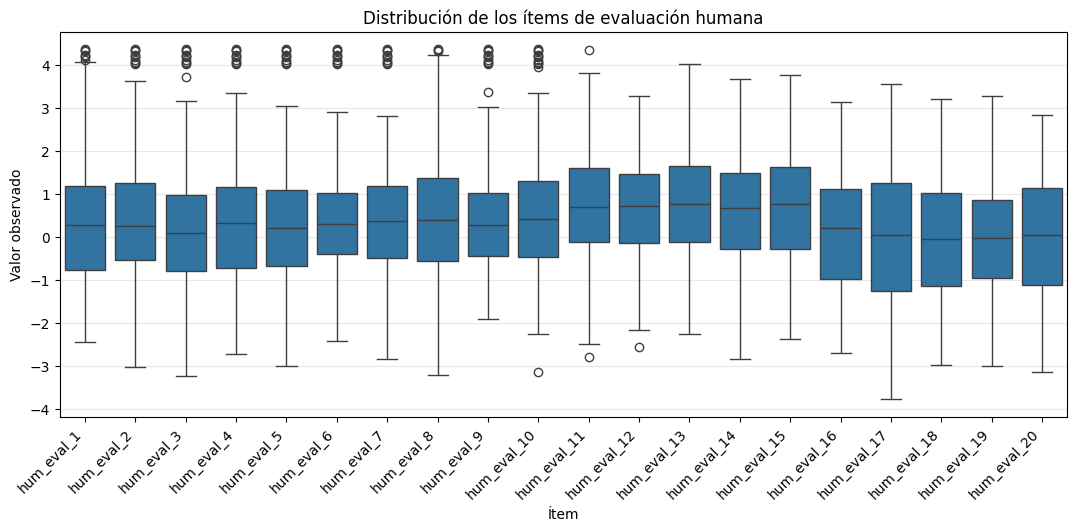

In [7]:
def graficar_boxplots_items(datos, titulo):
    """
    Genera boxplots para revisar la distribución de los ítems.
    """
    datos_largos = datos.melt(var_name="item", value_name="valor")

    plt.figure(figsize=(13, 5))
    sns.boxplot(data=datos_largos, x="item", y="valor")
    plt.title(titulo)
    plt.xlabel("Ítem")
    plt.ylabel("Valor observado")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


graficar_boxplots_items(
    datos_humanos,
    "Distribución de los ítems de evaluación humana"
)


### Especificación teórica del modelo CFA

Se plantea una estructura balanceada de cinco ítems por constructo:

- **Calidad:** `hum_eval_1` a `hum_eval_5`
- **Seguridad:** `hum_eval_6` a `hum_eval_10`
- **Creatividad:** `hum_eval_11` a `hum_eval_15`
- **Sesgo:** `hum_eval_16` a `hum_eval_20`

El modelo permite correlaciones entre factores, una decisión razonable porque las dimensiones de evaluación humana no tienen por qué ser independientes.


In [8]:
estructura_constructos = {
    "Calidad": [f"hum_eval_{i}" for i in range(1, 6)],
    "Seguridad": [f"hum_eval_{i}" for i in range(6, 11)],
    "Creatividad": [f"hum_eval_{i}" for i in range(11, 16)],
    "Sesgo": [f"hum_eval_{i}" for i in range(16, 21)]
}

for factor, items in estructura_constructos.items():
    print(f"{factor}: {items}")


Calidad: ['hum_eval_1', 'hum_eval_2', 'hum_eval_3', 'hum_eval_4', 'hum_eval_5']
Seguridad: ['hum_eval_6', 'hum_eval_7', 'hum_eval_8', 'hum_eval_9', 'hum_eval_10']
Creatividad: ['hum_eval_11', 'hum_eval_12', 'hum_eval_13', 'hum_eval_14', 'hum_eval_15']
Sesgo: ['hum_eval_16', 'hum_eval_17', 'hum_eval_18', 'hum_eval_19', 'hum_eval_20']


In [9]:
def construir_modelo_cfa(estructura):
    """
    Construye la sintaxis CFA para semopy.
    También permite correlación entre todos los factores latentes.
    """
    lineas = []

    for factor, items in estructura.items():
        lineas.append(f"{factor} =~ " + " + ".join(items))

    factores = list(estructura.keys())
    for i in range(len(factores)):
        for j in range(i + 1, len(factores)):
            lineas.append(f"{factores[i]} ~~ {factores[j]}")

    return "\n".join(lineas)


modelo_cfa = construir_modelo_cfa(estructura_constructos)
print(modelo_cfa)


Calidad =~ hum_eval_1 + hum_eval_2 + hum_eval_3 + hum_eval_4 + hum_eval_5
Seguridad =~ hum_eval_6 + hum_eval_7 + hum_eval_8 + hum_eval_9 + hum_eval_10
Creatividad =~ hum_eval_11 + hum_eval_12 + hum_eval_13 + hum_eval_14 + hum_eval_15
Sesgo =~ hum_eval_16 + hum_eval_17 + hum_eval_18 + hum_eval_19 + hum_eval_20
Calidad ~~ Seguridad
Calidad ~~ Creatividad
Calidad ~~ Sesgo
Seguridad ~~ Creatividad
Seguridad ~~ Sesgo
Creatividad ~~ Sesgo


### Estimación del modelo CFA

Los ítems se estandarizan antes de estimar el CFA para que las cargas factoriales sean comparables. La estimación converge correctamente, por lo que los índices de ajuste y las cargas pueden interpretarse.


In [10]:
datos_humanos_std = estandarizar_dataframe(datos_humanos)

display(datos_humanos_std.describe().T[["mean", "std"]].round(3))


,mean,std
hum_eval_1,0.0,1.003
hum_eval_2,0.0,1.003
hum_eval_3,0.0,1.003
hum_eval_4,-0.0,1.003
hum_eval_5,0.0,1.003
hum_eval_6,0.0,1.003
hum_eval_7,-0.0,1.003
hum_eval_8,0.0,1.003
hum_eval_9,0.0,1.003
hum_eval_10,-0.0,1.003


In [11]:
def ajustar_cfa(modelo_cfa, datos_estandarizados):
    """
    Ajusta un modelo CFA con semopy.
    """
    modelo = Model(modelo_cfa)
    resultado = modelo.fit(datos_estandarizados)
    print(resultado)
    return modelo


cfa = ajustar_cfa(modelo_cfa, datos_humanos_std)


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.963
Number of iterations: 70
Params: 1.006 1.020 0.987 1.009 1.047 1.071 1.067 1.042 0.962 0.953 0.903 0.978 1.017 1.026 0.947 1.013 0.577 -0.187 -0.368 0.778 -0.194 -0.307 0.697 0.343 0.737 0.745 0.222 0.243 0.263 0.317 0.330 0.399 0.295 0.255 0.229 0.216 0.332 0.212 0.235 0.191 0.242 0.207 0.303 0.236 0.200 0.206


### Índices de bondad de ajuste

Se revisan los índices globales del modelo: \(\chi^2\), CFI, TLI, RMSEA y SRMR. Si `semopy` no reporta SRMR directamente, se calcula a partir de la diferencia entre la matriz de correlaciones observada y la matriz de correlaciones implícita por el modelo.


In [12]:
def calcular_srmr(modelo, datos_estandarizados):
    """
    Calcula SRMR como la raíz del promedio de residuos cuadrados entre
    las matrices de correlación observada e implícita por el modelo.
    """
    try:
        observadas = list(modelo.vars.get("observed", datos_estandarizados.columns))
        datos_modelo = datos_estandarizados[observadas]
        matriz_observada = datos_modelo.cov().values

        sigma = modelo.calc_sigma()
        if isinstance(sigma, tuple):
            sigma = sigma[0]
        matriz_implicita = np.asarray(sigma)

        if matriz_observada.shape != matriz_implicita.shape:
            return np.nan

        def cov_a_corr(matriz):
            desviaciones = np.sqrt(np.diag(matriz))
            return matriz / np.outer(desviaciones, desviaciones)

        corr_observada = cov_a_corr(matriz_observada)
        corr_implicita = cov_a_corr(matriz_implicita)
        residuos = corr_observada - corr_implicita
        triangulo_inferior = np.tril_indices_from(residuos, k=-1)

        return float(np.sqrt(np.mean(residuos[triangulo_inferior] ** 2)))
    except Exception:
        return np.nan


def extraer_indices_ajuste(modelo, datos_estandarizados=None):
    """
    Extrae los índices principales de ajuste desde semopy.calc_stats.
    Si SRMR no está disponible, intenta calcularlo manualmente.
    """
    estadisticos = calc_stats(modelo)
    fila = estadisticos.loc["Value"] if "Value" in estadisticos.index else estadisticos.iloc[0]

    indices_interes = ["chi2", "DoF", "chi2 p-value", "CFI", "TLI", "RMSEA", "SRMR"]
    valores = [fila[indice] if indice in fila.index else np.nan for indice in indices_interes]

    tabla = pd.DataFrame({
        "indicador": indices_interes,
        "valor": valores
    })

    if datos_estandarizados is not None:
        mascara_srmr = tabla["indicador"] == "SRMR"
        if tabla.loc[mascara_srmr, "valor"].isna().all():
            tabla.loc[mascara_srmr, "valor"] = calcular_srmr(modelo, datos_estandarizados)

    return tabla


tabla_indices_cfa = extraer_indices_ajuste(cfa, datos_humanos_std)
display(tabla_indices_cfa.round(3))

if tabla_indices_cfa.loc[tabla_indices_cfa["indicador"] == "SRMR", "valor"].isna().all():
    print("Nota: no fue posible obtener SRMR desde semopy ni calcularlo manualmente con la API disponible.")


,indicador,valor
0,chi2,192.536
1,DoF,164.000
2,chi2 p-value,0.063
3,CFI,0.992
4,TLI,0.991
5,RMSEA,0.030
6,SRMR,0.045


### Interpretación de los índices de ajuste

Los resultados respaldan la estructura de cuatro factores. El modelo presenta \(\chi^2 = 192.536\) con 164 grados de libertad y un valor-p de 0.063; al ser mayor que 0.05, no se rechaza el ajuste global bajo este criterio. Los índices incrementales son altos (**CFI = 0.992**, **TLI = 0.991**) y el error de aproximación es bajo (**RMSEA = 0.030**).

La tabla de ajuste incorpora además SRMR. Este indicador evalúa el tamaño promedio de los residuos estandarizados entre correlaciones observadas e implícitas; valores inferiores a 0.08 suelen considerarse aceptables. En conjunto, los indicadores disponibles apoyan un buen ajuste del CFA y respaldan la estructura de cuatro constructos.


### Cargas factoriales

Las cargas factoriales indican qué tan bien cada ítem representa a su factor latente. Como referencia, cargas superiores a 0.40 son aceptables y cargas superiores a 0.70 son fuertes.


In [13]:
def extraer_cargas_factoriales(modelo, factores):
    """
    Extrae cargas factoriales estandarizadas desde semopy.
    """
    parametros = modelo.inspect(std_est=True)
    columna_estandarizada = "Est. Std" if "Est. Std" in parametros.columns else "Estimate"

    cargas = parametros[
        (parametros["op"] == "~") &
        (parametros["rval"].isin(factores))
    ].copy()

    cargas = cargas.rename(columns={
        "lval": "item",
        "rval": "factor",
        "Estimate": "carga_no_estandarizada",
        columna_estandarizada: "carga_estandarizada"
    })

    columnas = [
        "factor", "item", "carga_no_estandarizada",
        "carga_estandarizada", "p-value"
    ]

    return cargas[columnas], parametros, columna_estandarizada


factores_cfa = list(estructura_constructos.keys())

cargas_cfa, parametros_cfa, columna_estandarizada_cfa = extraer_cargas_factoriales(
    cfa,
    factores_cfa
)

display(cargas_cfa.round(4))


,factor,item,carga_no_estandarizada,carga_estandarizada,p-value
0,Calidad,hum_eval_1,1.0000,0.8820,-
1,Calidad,hum_eval_2,1.0062,0.8875,0.0
2,Calidad,hum_eval_3,1.0197,0.8994,0.0
3,Calidad,hum_eval_4,0.9870,0.8706,0.0
4,Calidad,hum_eval_5,1.0095,0.8904,0.0
5,Seguridad,hum_eval_6,1.0000,0.8351,-
6,Seguridad,hum_eval_7,1.0466,0.8739,0.0
7,Seguridad,hum_eval_8,1.0713,0.8946,0.0
8,Seguridad,hum_eval_9,1.0673,0.8912,0.0
9,Seguridad,hum_eval_10,1.0423,0.8703,0.0


In [14]:
resumen_cargas_cfa = cargas_cfa.groupby("factor")["carga_estandarizada"].agg(
    minima="min",
    promedio="mean",
    maxima="max"
)

display(resumen_cargas_cfa.round(4))


,minima,promedio,maxima
factor,,,
Calidad,0.8706,0.8860,0.8994
Creatividad,0.7754,0.8236,0.8585
Seguridad,0.8351,0.8730,0.8946
Sesgo,0.8173,0.8638,0.8854


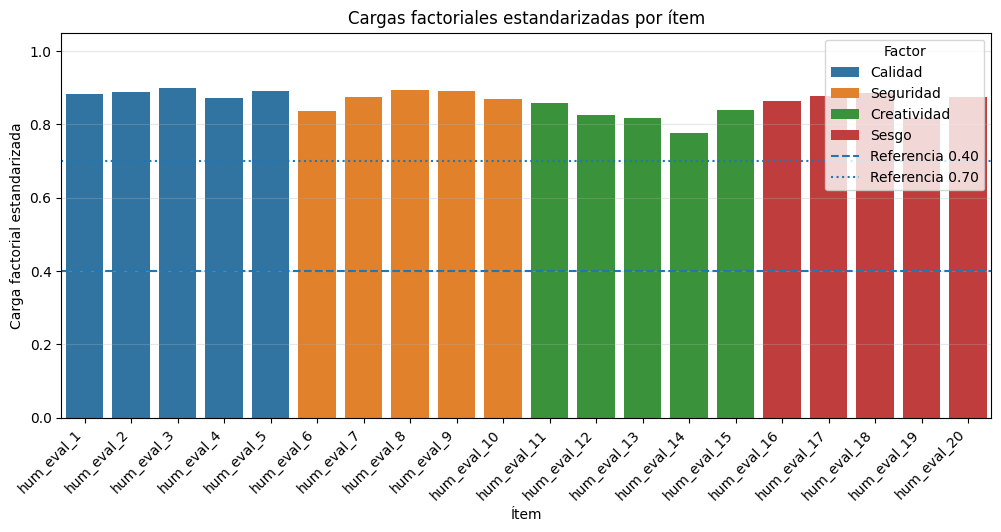

In [15]:
def graficar_cargas_factoriales(cargas):
    """
    Grafica las cargas factoriales estandarizadas por ítem.
    """
    plt.figure(figsize=(12, 5))

    sns.barplot(
        data=cargas,
        x="item",
        y="carga_estandarizada",
        hue="factor"
    )

    plt.axhline(0.40, linestyle="--", label="Referencia 0.40")
    plt.axhline(0.70, linestyle=":", label="Referencia 0.70")
    plt.title("Cargas factoriales estandarizadas por ítem")
    plt.xlabel("Ítem")
    plt.ylabel("Carga factorial estandarizada")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Factor")
    plt.show()


graficar_cargas_factoriales(cargas_cfa)


### Correlaciones entre factores

Las cargas estandarizadas son altas en todos los constructos: Calidad promedia 0.886, Seguridad 0.873, Creatividad 0.824 y Sesgo 0.864. La carga mínima observada es 0.775, todavía por encima del umbral fuerte de 0.70. Esto aporta evidencia de validez convergente.

Las correlaciones entre factores también son sustantivas. Calidad y Seguridad se asocian positivamente (0.784), mientras que ambas se relacionan negativamente con Sesgo. Creatividad se relaciona positivamente con Sesgo (0.462) y negativamente con Calidad y Seguridad. Este patrón es coherente con la idea de que mayor riesgo de sesgo tiende a alejarse de evaluaciones de calidad y seguridad, aunque puede aparecer junto con mayor creatividad.


In [16]:
def extraer_correlaciones_factores(parametros, factores, columna_estandarizada):
    """
    Extrae las correlaciones/covarianzas estandarizadas entre factores latentes.
    """
    correlaciones = parametros[
        (parametros["op"] == "~~") &
        (parametros["lval"].isin(factores)) &
        (parametros["rval"].isin(factores)) &
        (parametros["lval"] != parametros["rval"])
    ].copy()

    correlaciones = correlaciones.rename(columns={
        "lval": "factor_1",
        "rval": "factor_2",
        columna_estandarizada: "correlacion_estandarizada"
    })

    return correlaciones[["factor_1", "factor_2", "correlacion_estandarizada", "p-value"]]


correlaciones_factores_cfa = extraer_correlaciones_factores(
    parametros_cfa,
    factores_cfa,
    columna_estandarizada_cfa
)

display(correlaciones_factores_cfa.round(4))


,factor_1,factor_2,correlacion_estandarizada,p-value
20,Calidad,Seguridad,0.7840,0.0
21,Calidad,Creatividad,-0.2471,0.001745
22,Calidad,Sesgo,-0.4834,0.0
24,Seguridad,Creatividad,-0.2708,0.000723
25,Seguridad,Sesgo,-0.4254,0.000001
27,Creatividad,Sesgo,0.4623,0.0


### Cierre de la sección

El sub-instrumento humano muestra una estructura factorial consistente con la hipótesis teórica. Los índices de ajuste global son buenos y las cargas factoriales son altas en los cuatro constructos.

Por tanto, **Calidad**, **Seguridad**, **Creatividad** y **Sesgo** pueden usarse como dimensiones válidas para apoyar la interpretación posterior de los clústeres. La correlación positiva entre Calidad y Seguridad, junto con la relación negativa de estas dimensiones con Sesgo, ofrece una lectura sustantiva útil para el perfilamiento final.


## Reducción de Dimensionalidad y Extracción de Características (EFA/PC)

Después de validar el sub-instrumento humano, se analiza la matriz completa del estudio. A diferencia del CFA, aquí no se busca confirmar una estructura teórica de 20 ítems, sino construir un espacio reducido a partir de las 3000 variables disponibles.

El problema central es la alta dimensionalidad: \(p = 3000\) variables frente a \(n = 200\) observaciones. En esta condición, la matriz de covarianza es singular o inestable. Por ello se utiliza extracción mediante Componentes Principales y posterior rotación Varimax para facilitar la interpretación.


### Preparación de la matriz completa

Se excluye `prompt_id` y se conservan las 3000 variables numéricas. La matriz resultante no presenta valores faltantes después de la imputación simple aplicada en la función de preparación.


In [17]:
def preparar_matriz_completa(df, columna_id="prompt_id"):
    """
    Prepara la matriz completa de análisis excluyendo la columna identificadora.
    """
    variables = [col for col in df.columns if col != columna_id]
    X = df[variables].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.mean())

    print(f"Dimensiones de la matriz completa X: {X.shape}")
    print(f"Valores faltantes totales después de imputación simple: {X.isna().sum().sum()}")

    return X, variables


columna_id = "prompt_id"
X, variables_analisis = preparar_matriz_completa(df, columna_id=columna_id)
mostrar_vista_compacta(X, filas=5, columnas=10)


Dimensiones de la matriz completa X: (200, 3000)
Valores faltantes totales después de imputación simple: 0
Vista compacta: 5 filas y 10 de 3000 columnas totales.


,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10
0,-0.339,-0.287,0.729,0.861,1.186,2.184,1.427,2.025,0.993,2.310
1,0.575,0.308,0.526,-1.777,0.245,-0.727,-0.790,-1.360,0.137,-0.569
2,1.271,-0.691,2.079,1.061,0.470,0.083,0.706,1.720,0.551,1.522
3,-0.906,0.478,0.386,-0.789,-0.180,0.677,-0.509,0.143,-0.040,0.001
4,-0.102,0.117,0.994,1.092,-0.333,0.587,-0.525,-2.120,0.093,0.424


### Implicación de la alta dimensionalidad

La matriz contiene 3000 variables y 200 observaciones. Por tanto, el rango máximo posible de la matriz de covarianza es 199, muy inferior al número de variables. Esto impide invertir la matriz de covarianza de forma estable y justifica usar PCA como estrategia de reducción.


In [18]:
def resumir_alta_dimensionalidad(X):
    """
    Resume formalmente el problema p >> n.
    """
    n, p = X.shape
    rango_maximo = min(n - 1, p)

    tabla = pd.DataFrame({
        "Elemento": [
            "Número de observaciones",
            "Número de variables",
            "Rango máximo posible de la matriz de covarianza"
        ],
        "Valor": [n, p, rango_maximo]
    })

    display(tabla)

    print(
        f"La matriz de covarianza tendría dimensión {p} x {p}, "
        f"pero su rango máximo posible es {rango_maximo}. "
        "Por tanto, es singular o no invertible de forma estable."
    )

    return n, p, rango_maximo


n, p, rango_maximo = resumir_alta_dimensionalidad(X)


La matriz de covarianza tendría dimensión 3000 x 3000, pero su rango máximo posible es 199. Por tanto, es singular o no invertible de forma estable.


,Elemento,Valor
0,Número de observaciones,200
1,Número de variables,3000
2,Rango máximo posible de la matriz de covarianza,199


### Estandarización de la matriz completa

PCA depende de la escala de medición. Por esta razón, todas las variables se estandarizan antes de la extracción para que ninguna domine los componentes solo por su varianza original.


In [19]:
X_std = estandarizar_dataframe(X)

display(X_std.iloc[:, :10].describe().T[["mean", "std"]].round(3))


,mean,std
hum_eval_1,0.0,1.003
hum_eval_2,0.0,1.003
hum_eval_3,0.0,1.003
hum_eval_4,-0.0,1.003
hum_eval_5,0.0,1.003
hum_eval_6,0.0,1.003
hum_eval_7,-0.0,1.003
hum_eval_8,0.0,1.003
hum_eval_9,0.0,1.003
hum_eval_10,-0.0,1.003


### Extracción por Componentes Principales

PCA permite representar las 3000 variables originales mediante un número menor de componentes ortogonales. Esta decisión reduce ruido, evita trabajar directamente en un espacio sobredimensionado y produce una base más adecuada para clustering.


In [20]:
def ajustar_pca(X_std):
    """
    Ajusta PCA usando el máximo número posible de componentes informativos.
    """
    n, p = X_std.shape
    componentes_maximos = min(n - 1, p)

    pca = PCA(n_components=componentes_maximos, random_state=42)
    pca.fit(X_std)

    varianza_explicada = pca.explained_variance_ratio_
    varianza_acumulada = np.cumsum(varianza_explicada)

    tabla_varianza = pd.DataFrame({
        "componente": np.arange(1, componentes_maximos + 1),
        "varianza_explicada": varianza_explicada,
        "varianza_acumulada": varianza_acumulada
    })

    return pca, tabla_varianza


pca, tabla_varianza = ajustar_pca(X_std)

display(tabla_varianza.head(20).round(4))


,componente,varianza_explicada,varianza_acumulada
0,1,0.0577,0.0577
1,2,0.0484,0.1061
2,3,0.0287,0.1348
3,4,0.0278,0.1626
4,5,0.0258,0.1884
5,6,0.0234,0.2118
6,7,0.0209,0.2327
7,8,0.0204,0.2531
8,9,0.0182,0.2714
9,10,0.0168,0.2882


### Scree plot y varianza explicada acumulada

La selección del número de componentes combina el gráfico de sedimentación y la varianza acumulada. En contextos de clustering, no siempre conviene retener tantos componentes como sea necesario para alcanzar 70% o 80% de varianza, porque eso puede reintroducir ruido y dificultar la interpretación.

Por eso se reportan ambos criterios: el codo como solución operativa y los umbrales de varianza acumulada como referencia de cuánto costaría retener una proporción alta de información total.


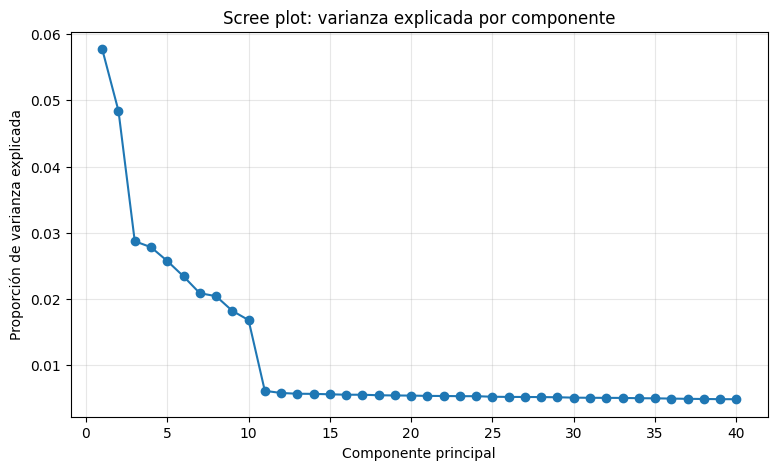

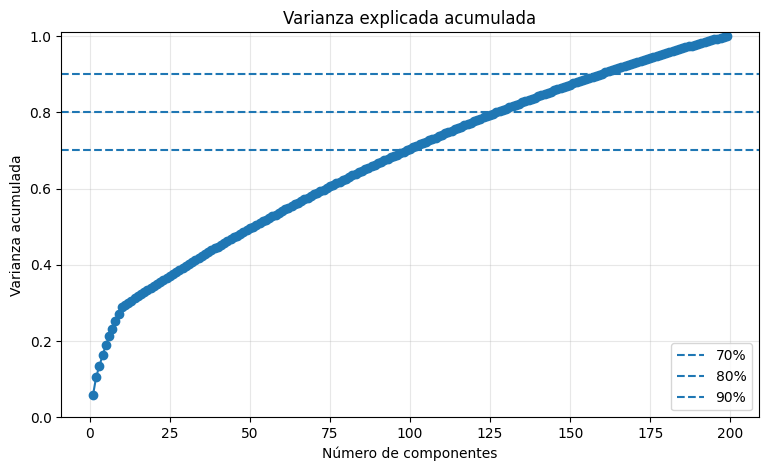

In [21]:
def graficar_scree_plot(tabla_varianza, max_componentes=40):
    """
    Grafica la varianza explicada por componente.
    """
    datos = tabla_varianza.head(max_componentes)

    plt.figure(figsize=(9, 5))
    plt.plot(datos["componente"], datos["varianza_explicada"], marker="o")
    plt.title("Scree plot: varianza explicada por componente")
    plt.xlabel("Componente principal")
    plt.ylabel("Proporción de varianza explicada")
    plt.grid(alpha=0.3)
    plt.show()


def graficar_varianza_acumulada(tabla_varianza):
    """
    Grafica la varianza acumulada.
    """
    plt.figure(figsize=(9, 5))
    plt.plot(
        tabla_varianza["componente"],
        tabla_varianza["varianza_acumulada"],
        marker="o"
    )
    plt.axhline(0.70, linestyle="--", label="70%")
    plt.axhline(0.80, linestyle="--", label="80%")
    plt.axhline(0.90, linestyle="--", label="90%")
    plt.title("Varianza explicada acumulada")
    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza acumulada")
    plt.ylim(0, 1.01)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


graficar_scree_plot(tabla_varianza, max_componentes=40)
graficar_varianza_acumulada(tabla_varianza)


In [22]:
def calcular_componentes_por_umbral(tabla_varianza, umbrales=(0.70, 0.80, 0.90)):
    """
    Calcula cuántos componentes se requieren para alcanzar distintos umbrales de varianza acumulada.
    """
    varianza_acumulada = tabla_varianza["varianza_acumulada"].values

    tabla_umbrales = pd.DataFrame({
        "umbral": umbrales,
        "componentes_necesarios": [
            np.argmax(varianza_acumulada >= umbral) + 1
            for umbral in umbrales
        ]
    })

    return tabla_umbrales


tabla_umbrales = calcular_componentes_por_umbral(tabla_varianza)

display(tabla_umbrales)


,umbral,componentes_necesarios
0,0.7,99
1,0.8,128
2,0.9,160


In [23]:
def detectar_codo(varianza_explicada, max_componentes=40):
    """
    Detecta el codo del Scree Plot usando la distancia máxima a la línea
    entre el primer y último punto considerados.
    """
    y = np.asarray(varianza_explicada[:max_componentes])
    x = np.arange(1, len(y) + 1)

    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    punto_inicial = np.array([x_norm[0], y_norm[0]])
    punto_final = np.array([x_norm[-1], y_norm[-1]])
    puntos = np.column_stack([x_norm, y_norm])

    distancias = np.abs(
        np.cross(
            punto_final - punto_inicial,
            punto_inicial - puntos
        )
    ) / np.linalg.norm(punto_final - punto_inicial)

    return int(x[np.argmax(distancias)])


def resumir_decision_componentes(tabla_varianza, tabla_umbrales, m_codo):
    """
    Resume la decisión de componentes comparando codo y umbrales de varianza.
    """
    filas = [{
        "criterio": "Codo del scree plot",
        "componentes": m_codo,
        "varianza_acumulada": tabla_varianza.loc[
            tabla_varianza["componente"] == m_codo,
            "varianza_acumulada"
        ].iloc[0],
        "decision": "Solución retenida por parsimonia"
    }]

    for _, fila in tabla_umbrales.iterrows():
        componentes = int(fila["componentes_necesarios"])
        filas.append({
            "criterio": f"Varianza acumulada {int(fila['umbral'] * 100)}%",
            "componentes": componentes,
            "varianza_acumulada": tabla_varianza.loc[
                tabla_varianza["componente"] == componentes,
                "varianza_acumulada"
            ].iloc[0],
            "decision": "Referente informativo; no se retiene por baja parsimonia"
        })

    return pd.DataFrame(filas)


m_codo = detectar_codo(
    tabla_varianza["varianza_explicada"].values,
    max_componentes=40
)

m_retener = m_codo
varianza_retenida = tabla_varianza.loc[
    tabla_varianza["componente"] == m_retener,
    "varianza_acumulada"
].iloc[0]

tabla_decision_componentes = resumir_decision_componentes(
    tabla_varianza=tabla_varianza,
    tabla_umbrales=tabla_umbrales,
    m_codo=m_codo
)

display(tabla_decision_componentes.round(4))

print(f"Número de componentes retenido: m = {m_retener}")
print(f"Varianza acumulada retenida: {varianza_retenida:.4f}")


Número de componentes retenido: m = 11
Varianza acumulada retenida: 0.2944


,criterio,componentes,varianza_acumulada,decision
0,Codo del scree plot,11,0.2944,Solución retenida por parsimonia
1,Varianza acumulada 70%,99,0.7005,Referente informativo; no se retiene por baja parsimonia
2,Varianza acumulada 80%,128,0.8032,Referente informativo; no se retiene por baja parsimonia
3,Varianza acumulada 90%,160,0.9017,Referente informativo; no se retiene por baja parsimonia


### Interpretación de la selección de componentes

El codo del scree plot sugiere retener **11 componentes**, que explican aproximadamente **29.44%** de la varianza acumulada. Los umbrales clásicos de 70%, 80% y 90% exigirían 99, 128 y 160 componentes, respectivamente.

Para este análisis se retienen 11 componentes porque el objetivo posterior es construir tipologías en un espacio bajo-dimensional, estable e interpretable. Retener cerca de 100 componentes aumentaría la varianza conservada, pero reduciría la parsimonia y haría menos clara la interpretación de perfiles. Por ello, la varianza acumulada se usa como criterio informativo y el codo como criterio operativo de retención.


### Puntuaciones PCA y rotación Varimax

Las puntuaciones representan cada prompt en el espacio reducido. Luego se aplica rotación Varimax para concentrar las cargas y mejorar la lectura de los factores retenidos.


In [24]:
def obtener_puntuaciones_pca(pca, X_std, m_retener):
    """
    Obtiene las puntuaciones de los primeros m componentes.
    """
    puntuaciones = pca.transform(X_std)[:, :m_retener]
    columnas_componentes = [f"PC{i}" for i in range(1, m_retener + 1)]

    df_puntuaciones = pd.DataFrame(
        puntuaciones,
        columns=columnas_componentes,
        index=X_std.index
    )

    return df_puntuaciones


df_puntuaciones_pca = obtener_puntuaciones_pca(pca, X_std, m_retener)
display(df_puntuaciones_pca.head())


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-3.762642,3.818123,-3.155322,9.929193,-9.796495,-10.005448,-3.786385,15.099277,0.424357,-0.093480,5.565281
1,-21.611601,3.091203,-4.868995,19.179669,-3.266265,-5.070660,-18.077943,-4.363461,-2.369366,4.767542,-1.863564
2,9.646840,-6.320652,-2.674794,0.121550,8.580772,-8.937765,-1.373618,1.033195,3.805386,16.582735,2.655355
3,-17.527348,-0.486739,-1.715500,9.992099,11.155138,-7.939487,0.624458,-13.779531,6.829820,2.392221,0.559925
4,-36.911566,14.203972,13.403279,-1.337587,-4.905458,2.893842,11.254652,9.573722,-8.986628,-7.244087,-1.784802


In [25]:
def rotar_varimax_pca(pca, puntuaciones_pca, variables_analisis, m_retener):
    """
    Aplica rotación Varimax a las cargas de PCA y rota las puntuaciones.
    """
    cargas_pca = pca.components_[:m_retener].T * np.sqrt(
        pca.explained_variance_[:m_retener]
    )

    rotador = Rotator(method="varimax")
    cargas_rotadas = rotador.fit_transform(cargas_pca)

    puntuaciones_rotadas = puntuaciones_pca.values @ rotador.rotation_

    columnas_factores = [f"F{i}" for i in range(1, m_retener + 1)]

    df_cargas_rotadas = pd.DataFrame(
        cargas_rotadas,
        index=variables_analisis,
        columns=columnas_factores
    )

    df_puntuaciones_factoriales = pd.DataFrame(
        puntuaciones_rotadas,
        columns=columnas_factores,
        index=puntuaciones_pca.index
    )

    return df_cargas_rotadas, df_puntuaciones_factoriales


df_cargas_rotadas, df_puntuaciones_factoriales = rotar_varimax_pca(
    pca,
    df_puntuaciones_pca,
    variables_analisis,
    m_retener
)

print("Dimensiones de la matriz de puntuaciones factoriales:", df_puntuaciones_factoriales.shape)


Dimensiones de la matriz de puntuaciones factoriales: (200, 11)


### Variables más asociadas a cada factor rotado

Las variables con mayor carga absoluta permiten interpretar cada factor. En los primeros diez factores predominan variables internas `int_metric_*`, mientras que **F11** queda claramente asociado con los ítems humanos de Seguridad (`hum_eval_6` a `hum_eval_10`).

Para mantener el informe compacto se muestran solo las cinco variables más representativas de cada factor. Esto es suficiente para interpretar las dimensiones dominantes sin listar la matriz completa de cargas.


In [26]:
def obtener_top_variables_por_factor(df_cargas, top_n=5):
    """
    Obtiene las variables con mayor carga absoluta por cada factor.
    """
    filas = []

    for factor in df_cargas.columns:
        top = df_cargas[factor].abs().sort_values(ascending=False).head(top_n)

        for variable, carga_abs in top.items():
            filas.append({
                "factor": factor,
                "variable": variable,
                "carga_rotada": df_cargas.loc[variable, factor],
                "carga_abs": carga_abs
            })

    return pd.DataFrame(filas)


tabla_top_variables = obtener_top_variables_por_factor(df_cargas_rotadas, top_n=5)

display(tabla_top_variables.round(4))


,factor,variable,carga_rotada,carga_abs
0,F1,int_metric_1752,-0.6933,0.6933
1,F1,int_metric_1506,-0.6817,0.6817
2,F1,int_metric_276,0.6764,0.6764
3,F1,int_metric_1337,0.6650,0.6650
4,F1,int_metric_1491,-0.6491,0.6491
5,F2,int_metric_2068,-0.6734,0.6734
6,F2,int_metric_2028,-0.6495,0.6495
7,F2,int_metric_842,-0.6235,0.6235
8,F2,int_metric_441,0.6066,0.6066
9,F2,int_metric_2134,0.6002,0.6002


### Matriz final de características reducidas

La matriz reducida `Z_factorial` tiene dimensión **200 x 11**. Esta matriz resume la información de las 3000 variables originales y será la entrada del análisis de tipologías.


In [27]:
Z_factorial = df_puntuaciones_factoriales.copy()

print("Dimensiones de la matriz original:", X.shape)
print("Dimensiones de la matriz reducida:", Z_factorial.shape)
mostrar_vista_compacta(Z_factorial, filas=5, columnas=11)


Dimensiones de la matriz original: (200, 3000)
Dimensiones de la matriz reducida: (200, 11)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,-2.833,8.777,3.364,9.003,-15.081,-2.194,-9.746,6.285,-5.585,-0.320,5.601
1,-22.045,14.350,5.596,0.770,0.840,0.248,-19.951,-9.446,-7.922,2.452,-1.268
2,3.555,-11.933,-2.334,12.361,4.738,-4.112,-6.882,0.663,2.662,13.456,2.141
3,-16.613,4.402,3.050,3.996,19.146,-8.887,-7.320,-2.115,-0.708,-3.694,1.492
4,-17.670,28.771,11.150,-3.147,4.833,12.761,12.545,18.895,-9.155,-8.150,-2.787


### Cierre de la sección

La reducción de dimensionalidad es metodológicamente necesaria porque la matriz original presenta una condición clara \(p \gg n\). PCA permite construir una representación más estable y manejable de los prompts.

Se retienen 11 componentes por criterio de codo y se aplica rotación Varimax para mejorar la interpretación. La matriz `Z_factorial` conserva dimensiones dominadas principalmente por métricas internas y una dimensión asociada a Seguridad humana, lo que será útil para perfilar los clústeres.


## Identificación de Tipologías

En esta sección se identifican grupos de prompts a partir de la matriz reducida `Z_factorial`. No se realiza clustering sobre las 3000 variables originales, porque las distancias en espacios de alta dimensionalidad suelen ser inestables y difíciles de interpretar.

Se comparan dos métodos: **K-Means** y **clustering jerárquico aglomerativo con método de Ward**. La selección se apoya en el coeficiente de silueta, el método del codo y la revisión de tamaños de grupo.


### Preparación de la matriz para clustering

Las puntuaciones factoriales se estandarizan nuevamente para que todos los factores contribuyan de manera comparable al cálculo de distancias.


In [28]:
Z_cluster = estandarizar_dataframe(Z_factorial)

print("Dimensiones de Z_cluster:", Z_cluster.shape)
display(Z_cluster.describe().T[["mean", "std"]].round(3))


Dimensiones de Z_cluster: (200, 11)


,mean,std
F1,0.0,1.003
F2,0.0,1.003
F3,0.0,1.003
F4,-0.0,1.003
F5,-0.0,1.003
F6,0.0,1.003
F7,0.0,1.003
F8,-0.0,1.003
F9,0.0,1.003
F10,0.0,1.003


### Evaluación de K-Means

K-Means se evalúa para distintos valores de \(k\). La inercia permite observar la reducción de variabilidad interna y el coeficiente de silueta resume la separación relativa entre clústeres.


In [29]:
def evaluar_kmeans(Z, rango_k=range(2, 11), random_state=42):
    """
    Evalúa K-Means para varios valores de k.
    """
    resultados = []

    for k in rango_k:
        modelo = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=50
        )

        etiquetas = modelo.fit_predict(Z)

        resultados.append({
            "k": k,
            "inercia": modelo.inertia_,
            "silueta": silhouette_score(Z, etiquetas)
        })

    return pd.DataFrame(resultados)


rango_k = range(2, 11)

tabla_kmeans = evaluar_kmeans(Z_cluster, rango_k=rango_k)

display(tabla_kmeans.round(4))


,k,inercia,silueta
0,2,2004.2217,0.0838
1,3,1863.9554,0.0847
2,4,1757.4139,0.0849
3,5,1674.5815,0.0864
4,6,1597.5179,0.0893
5,7,1540.7383,0.0877
6,8,1491.2186,0.0861
7,9,1450.1511,0.0924
8,10,1412.0143,0.0868


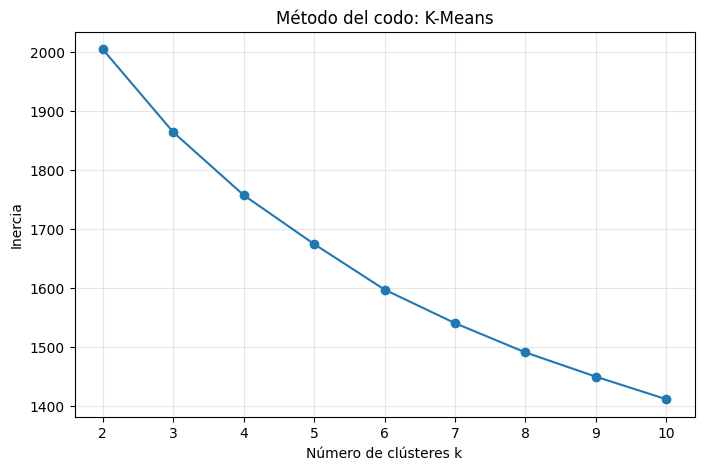

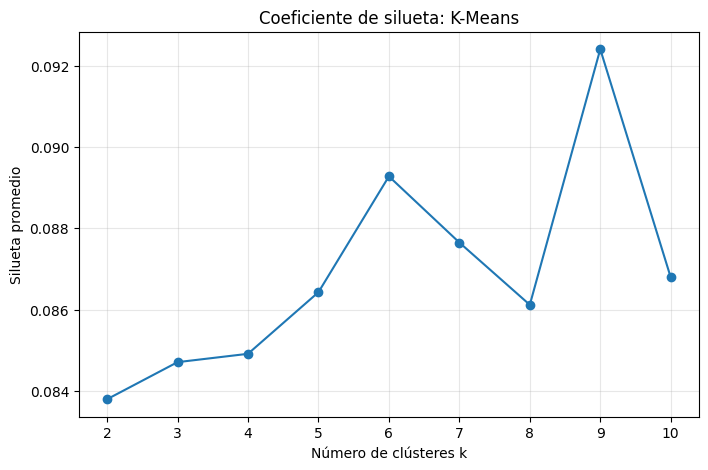

In [30]:
def graficar_resultados_kmeans(tabla_kmeans):
    """
    Grafica inercia y silueta de K-Means.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["inercia"], marker="o")
    plt.title("Método del codo: K-Means")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("Inercia")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["silueta"], marker="o")
    plt.title("Coeficiente de silueta: K-Means")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("Silueta promedio")
    plt.grid(alpha=0.3)
    plt.show()


graficar_resultados_kmeans(tabla_kmeans)


In [31]:
k_optimo_kmeans = int(tabla_kmeans.loc[tabla_kmeans["silueta"].idxmax(), "k"])
silueta_kmeans = tabla_kmeans["silueta"].max()

print(f"k óptimo según silueta en K-Means: {k_optimo_kmeans}")
print(f"Silueta máxima K-Means: {silueta_kmeans:.4f}")


k óptimo según silueta en K-Means: 9
Silueta máxima K-Means: 0.0924


### Solución K-Means final

El mayor coeficiente de silueta de K-Means se obtiene con **k = 9** y una silueta aproximada de **0.0924**. Aunque este es el mejor valor dentro del rango evaluado, la magnitud es baja; por tanto, los grupos deben interpretarse como tipologías exploratorias con separación moderada-débil, no como segmentos completamente nítidos.


In [32]:
def ajustar_kmeans_final(Z, k, random_state=42):
    """
    Ajusta K-Means final.
    """
    modelo = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=50
    )

    etiquetas = modelo.fit_predict(Z)

    return modelo, etiquetas


modelo_kmeans_final, clusters_kmeans = ajustar_kmeans_final(
    Z_cluster,
    k_optimo_kmeans
)

conteo_kmeans = pd.Series(clusters_kmeans).value_counts().sort_index()

display(
    conteo_kmeans
    .rename_axis("cluster_kmeans")
    .reset_index(name="cantidad_prompts")
)


,cluster_kmeans,cantidad_prompts
0,0,31
1,1,18
2,2,29
3,3,8
4,4,23
5,5,27
6,6,24
7,7,14
8,8,26


### Clustering jerárquico con método de Ward

El método de Ward construye una jerarquía de agrupamientos minimizando el aumento de varianza interna al fusionar grupos. El dendrograma se usa como apoyo visual para observar posibles cortes naturales.


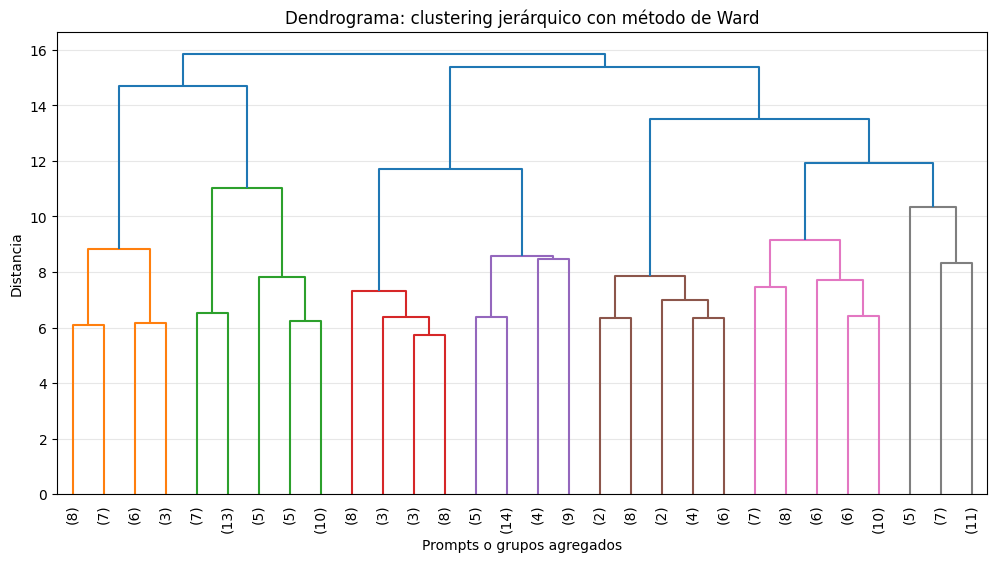

In [33]:
def graficar_dendrograma_ward(Z, p=30):
    """
    Calcula y grafica el dendrograma usando método de Ward.
    """
    matriz_linkage = linkage(Z, method="ward")

    plt.figure(figsize=(12, 6))
    dendrogram(
        matriz_linkage,
        truncate_mode="lastp",
        p=p,
        leaf_rotation=90,
        leaf_font_size=10
    )
    plt.title("Dendrograma: clustering jerárquico con método de Ward")
    plt.xlabel("Prompts o grupos agregados")
    plt.ylabel("Distancia")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    return matriz_linkage


matriz_linkage = graficar_dendrograma_ward(Z_cluster, p=30)


### Evaluación de Ward por silueta

Ward también se evalúa con distintos números de clústeres. Esta comparación permite revisar si una solución jerárquica ofrece una estructura más clara que K-Means.


In [34]:
def evaluar_ward(Z, rango_k=range(2, 11)):
    """
    Evalúa clustering jerárquico de Ward para varios valores de k.
    """
    resultados = []

    for k in rango_k:
        modelo = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )

        etiquetas = modelo.fit_predict(Z)

        resultados.append({
            "k": k,
            "silueta": silhouette_score(Z, etiquetas)
        })

    return pd.DataFrame(resultados)


tabla_ward = evaluar_ward(Z_cluster, rango_k=rango_k)

display(tabla_ward.round(4))


,k,silueta
0,2,0.0532
1,3,0.0518
2,4,0.0532
3,5,0.0620
4,6,0.0678
5,7,0.0711
6,8,0.0674
7,9,0.0732
8,10,0.0725


k óptimo según silueta en Ward: 9
Silueta máxima Ward: 0.0732


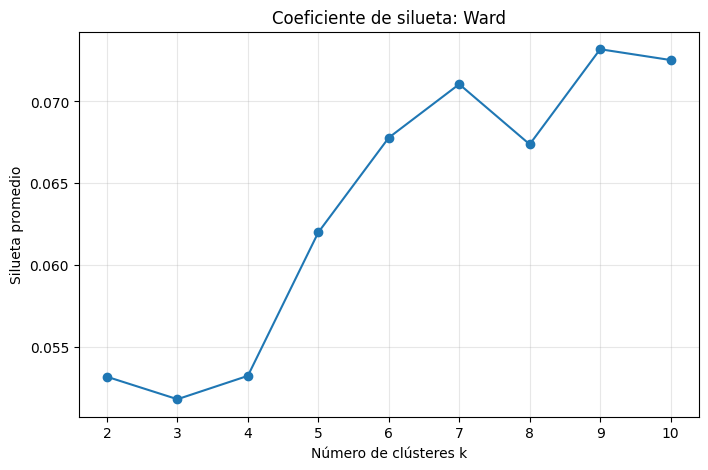

In [35]:
def graficar_silueta_ward(tabla_ward):
    """
    Grafica la silueta promedio para Ward.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_ward["k"], tabla_ward["silueta"], marker="o")
    plt.title("Coeficiente de silueta: Ward")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("Silueta promedio")
    plt.grid(alpha=0.3)
    plt.show()


graficar_silueta_ward(tabla_ward)

k_optimo_ward = int(tabla_ward.loc[tabla_ward["silueta"].idxmax(), "k"])
silueta_ward = tabla_ward["silueta"].max()

print(f"k óptimo según silueta en Ward: {k_optimo_ward}")
print(f"Silueta máxima Ward: {silueta_ward:.4f}")


### Comparación de métodos y selección de solución

La comparación favorece a **K-Means con k = 9**, con silueta de 0.0924 frente a 0.0732 en Ward. Ambos valores son bajos, lo que sugiere que la estructura de grupos no está fuertemente separada en el espacio factorial.

Aun así, K-Means ofrece la mejor alternativa relativa y produce tamaños de clúster razonables: el grupo más pequeño tiene 8 prompts y el más grande 31. La solución se considera la más robusta dentro de las alternativas evaluadas, pero su interpretación debe mantenerse exploratoria por la baja separación interna.


In [36]:
comparacion_modelos = pd.DataFrame({
    "modelo": ["K-Means", "Ward"],
    "k_optimo": [k_optimo_kmeans, k_optimo_ward],
    "silueta": [silueta_kmeans, silueta_ward]
})

display(comparacion_modelos.round(4))

modelo_recomendado = comparacion_modelos.loc[
    comparacion_modelos["silueta"].idxmax()
]

print("Modelo recomendado según silueta:")
print(modelo_recomendado)


Modelo recomendado según silueta:
modelo       K-Means
k_optimo           9
silueta     0.092408
Name: 0, dtype: object


,modelo,k_optimo,silueta
0,K-Means,9,0.0924
1,Ward,9,0.0732


In [37]:
def ajustar_modelo_final(Z, modelo_recomendado):
    """
    Ajusta el modelo final según la comparación de silueta.
    """
    modelo_nombre = modelo_recomendado["modelo"]
    k_final = int(modelo_recomendado["k_optimo"])

    if modelo_nombre == "K-Means":
        modelo, etiquetas = ajustar_kmeans_final(Z, k_final)
    else:
        modelo = AgglomerativeClustering(
            n_clusters=k_final,
            linkage="ward"
        )
        etiquetas = modelo.fit_predict(Z)

    return modelo_nombre, k_final, modelo, etiquetas


modelo_final_nombre, k_final, modelo_final, clusters_finales = ajustar_modelo_final(
    Z_cluster,
    modelo_recomendado
)

df_clusters = pd.DataFrame({
    columna_id: df[columna_id] if columna_id in df.columns else df.index,
    "cluster_kmeans": clusters_kmeans,
    "cluster_final": clusters_finales
})

print(f"Modelo final seleccionado: {modelo_final_nombre}")
print(f"Número final de clústeres: {k_final}")

display(df_clusters.head())


Modelo final seleccionado: K-Means
Número final de clústeres: 9


,prompt_id,cluster_kmeans,cluster_final
0,1,6,6
1,2,6,6
2,3,8,8
3,4,5,5
4,5,5,5


In [38]:
conteo_final = (
    df_clusters["cluster_final"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_final")
    .reset_index(name="cantidad_prompts")
)

display(conteo_final)


,cluster_final,cantidad_prompts
0,0,31
1,1,18
2,2,29
3,3,8
4,4,23
5,5,27
6,6,24
7,7,14
8,8,26


### Visualización de la solución final

La gráfica muestra la solución final usando solo las dos primeras dimensiones factoriales estandarizadas. Debe leerse como una proyección parcial: el clustering se calculó con los 11 factores, por lo que la superposición visual en dos dimensiones no invalida la solución, pero sí recuerda que la separación no es fuerte.


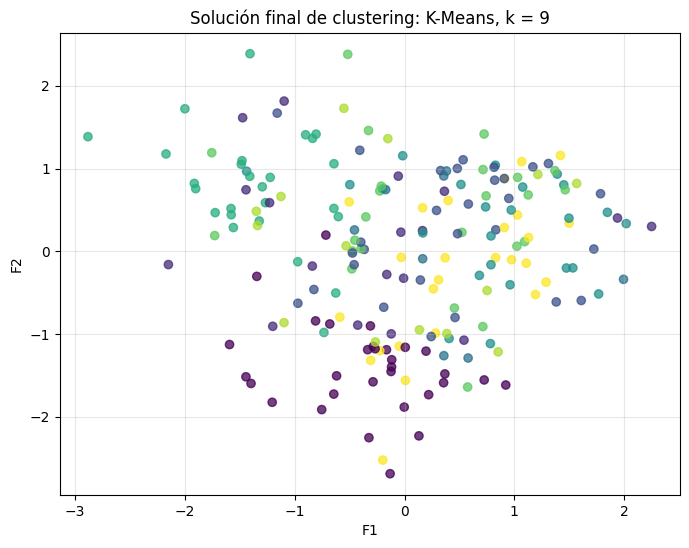

In [39]:
def graficar_clusters_2d(Z, etiquetas, titulo):
    """
    Visualiza los clústeres usando las dos primeras dimensiones factoriales.
    """
    columnas = Z.columns.tolist()

    plt.figure(figsize=(8, 6))
    plt.scatter(
        Z[columnas[0]],
        Z[columnas[1]],
        c=etiquetas,
        alpha=0.75
    )
    plt.title(titulo)
    plt.xlabel(columnas[0])
    plt.ylabel(columnas[1])
    plt.grid(alpha=0.3)
    plt.show()


graficar_clusters_2d(
    Z_cluster,
    clusters_finales,
    f"Solución final de clustering: {modelo_final_nombre}, k = {k_final}"
)


La identificación de tipologías se realizó sobre el espacio factorial reducido, una decisión adecuada dada la alta dimensionalidad original. La solución seleccionada fue **K-Means con 9 clústeres**, porque obtuvo la mejor silueta relativa frente a Ward.

La evidencia cuantitativa muestra separación débil entre grupos, por lo que las tipologías deben entenderse como perfiles exploratorios útiles para organizar patrones de prompts y orientar análisis posteriores, no como categorías definitivas. La variable `cluster_final` contiene la asignación que se utilizará para la caracterización conceptual.


## Caracterización e Interpretación de Perfiles

Esta sección transforma la asignación algorítmica de clústeres en perfiles interpretables. Para ello se combinan tres fuentes de información: los centroides en las dimensiones factoriales, los factores dominantes de cada grupo y los puntajes agregados de los constructos humanos validados.

El objetivo es describir qué caracteriza a cada grupo y qué implicaciones podría tener para evaluación, auditoría o fine-tuning del modelo NLA-7B.


### Construcción de la base de perfiles

Se integran las asignaciones de clúster con las puntuaciones factoriales originales y estandarizadas. Esta base permite calcular centroides y resumir el comportamiento promedio de cada conglomerado.


In [40]:
def construir_base_perfiles(df_clusters, Z_factorial, Z_cluster=None):
    """
    Construye una base de perfiles agregando las etiquetas de clúster
    a las puntuaciones factoriales.
    """
    if "cluster_final" not in df_clusters.columns:
        raise ValueError("df_clusters debe contener la columna 'cluster_final'.")

    base = Z_factorial.copy()
    base["cluster_final"] = df_clusters["cluster_final"].values

    if Z_cluster is not None:
        for columna in Z_cluster.columns:
            base[f"{columna}_std"] = Z_cluster[columna].values

    return base


base_perfiles = construir_base_perfiles(
    df_clusters=df_clusters,
    Z_factorial=Z_factorial,
    Z_cluster=Z_cluster
)

print("Dimensiones de la base de perfiles:", base_perfiles.shape)
mostrar_vista_compacta(base_perfiles, filas=5, columnas=12)


Dimensiones de la base de perfiles: (200, 23)
Vista compacta: 5 filas y 12 de 23 columnas totales.


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,cluster_final
0,-2.833,8.777,3.364,9.003,-15.081,-2.194,-9.746,6.285,-5.585,-0.320,5.601,6
1,-22.045,14.350,5.596,0.770,0.840,0.248,-19.951,-9.446,-7.922,2.452,-1.268,6
2,3.555,-11.933,-2.334,12.361,4.738,-4.112,-6.882,0.663,2.662,13.456,2.141,8
3,-16.613,4.402,3.050,3.996,19.146,-8.887,-7.320,-2.115,-0.708,-3.694,1.492,5
4,-17.670,28.771,11.150,-3.147,4.833,12.761,12.545,18.895,-9.155,-8.150,-2.787,5


### Centroides de las puntuaciones factoriales

Los centroides corresponden a las medias de las puntuaciones factoriales por clúster. Se calculan en dos escalas: puntuaciones rotadas originales y puntuaciones estandarizadas. La interpretación se basa principalmente en la versión estandarizada, porque permite comparar factores en una escala común.


In [41]:
def calcular_centroides(Z, etiquetas):
    """
    Calcula los centroides de una matriz Z agrupando por etiquetas de clúster.
    """
    tabla = Z.copy()
    tabla["cluster_final"] = etiquetas

    centroides = (
        tabla
        .groupby("cluster_final")
        .mean()
        .sort_index()
    )

    return centroides


centroides_factoriales = calcular_centroides(
    Z=Z_factorial,
    etiquetas=df_clusters["cluster_final"].values
)

centroides_estandarizados = calcular_centroides(
    Z=Z_cluster,
    etiquetas=df_clusters["cluster_final"].values
)

print("Centroides sobre puntuaciones factoriales rotadas:")
display(centroides_factoriales.round(3))

print("Centroides sobre puntuaciones factoriales estandarizadas:")
display(centroides_estandarizados.round(3))


Centroides sobre puntuaciones factoriales rotadas:
Centroides sobre puntuaciones factoriales estandarizadas:


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
cluster_final,,,,,,,,,,,
0,-4.356,-17.033,2.162,1.036,-5.950,4.066,-0.453,-1.891,-2.369,-0.822,0.971
1,-3.477,1.839,-0.212,-4.935,1.766,-5.383,-0.311,-4.473,0.063,2.037,7.028
2,5.022,3.527,-5.484,-6.958,2.209,4.912,3.135,-3.751,6.312,0.027,-2.358
3,5.036,-0.155,-15.673,3.821,-3.349,-4.774,-4.828,-6.528,-0.355,-14.617,3.499
4,10.768,3.130,4.206,8.736,0.374,1.015,4.358,-3.222,-4.894,-3.155,-2.293
5,-16.356,9.352,2.144,0.822,7.355,2.636,3.644,7.217,-3.761,-1.990,-0.508
6,2.421,5.338,5.586,-0.988,2.138,-0.368,-12.237,-0.535,-3.301,0.111,-1.657
7,-1.351,0.653,9.094,-1.294,-1.211,-0.390,5.582,4.796,9.311,6.769,3.661
8,6.400,-2.611,-7.494,1.794,-4.852,-8.218,-0.605,4.812,2.118,5.147,-2.356


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
cluster_final,,,,,,,,,,,
0,-0.347,-1.414,0.239,0.133,-0.679,0.491,-0.052,-0.225,-0.297,-0.103,0.221
1,-0.277,0.153,-0.023,-0.634,0.202,-0.650,-0.036,-0.533,0.008,0.256,1.601
2,0.400,0.293,-0.607,-0.893,0.252,0.594,0.359,-0.447,0.792,0.003,-0.537
3,0.401,-0.013,-1.736,0.491,-0.382,-0.577,-0.552,-0.778,-0.045,-1.837,0.797
4,0.858,0.260,0.466,1.122,0.043,0.123,0.498,-0.384,-0.614,-0.397,-0.522
5,-1.303,0.776,0.237,0.106,0.840,0.319,0.417,0.860,-0.472,-0.250,-0.116
6,0.193,0.443,0.619,-0.127,0.244,-0.044,-1.399,-0.064,-0.414,0.014,-0.378
7,-0.108,0.054,1.007,-0.166,-0.138,-0.047,0.638,0.571,1.168,0.851,0.834
8,0.510,-0.217,-0.830,0.230,-0.554,-0.993,-0.069,0.573,0.266,0.647,-0.537


### Interpretación de centroides factoriales

Cada fila representa un clúster y cada columna una dimensión factorial. Valores positivos indican que el clúster está por encima del promedio general en ese factor; valores negativos indican lo contrario.

Los contrastes más marcados ayudan a describir los grupos. Por ejemplo, el clúster 1 destaca en F11, dimensión asociada a ítems humanos de Seguridad, mientras que el clúster 3 presenta valores muy bajos en F10 y F3. Estos patrones serán más informativos cuando se combinen con los constructos humanos.


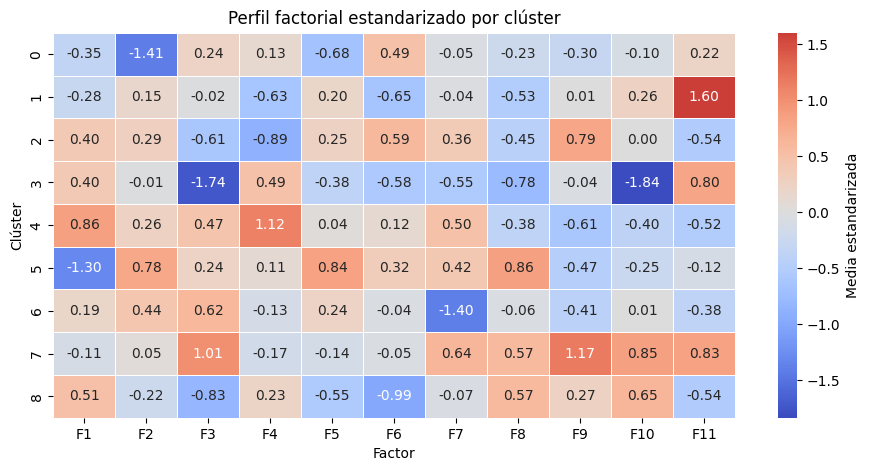

In [42]:
def graficar_centroides(centroides, titulo):
    """
    Grafica un mapa de calor de los centroides por clúster.
    """
    plt.figure(figsize=(11, 5))
    sns.heatmap(
        centroides,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Media estandarizada"}
    )
    plt.title(titulo)
    plt.xlabel("Factor")
    plt.ylabel("Clúster")
    plt.show()


graficar_centroides(
    centroides_estandarizados,
    "Perfil factorial estandarizado por clúster"
)


### Resumen factorial de cada clúster

Para facilitar la lectura, se identifican los tres factores más altos y los tres más bajos de cada clúster. Esta tabla resume qué dimensiones diferencian más a cada grupo.


In [43]:
def resumir_perfiles_factoriales(centroides, conteo_clusters, n_factores=3):
    """
    Resume cada clúster usando sus factores con centroides más altos y más bajos.
    """
    conteo = conteo_clusters.set_index("cluster_final")["cantidad_prompts"]

    filas = []

    for cluster, valores in centroides.iterrows():
        factores_altos = valores.sort_values(ascending=False).head(n_factores)
        factores_bajos = valores.sort_values(ascending=True).head(n_factores)

        filas.append({
            "cluster_final": cluster,
            "cantidad_prompts": int(conteo.loc[cluster]) if cluster in conteo.index else np.nan,
            "factores_mas_altos": ", ".join([f"{idx} ({val:.2f})" for idx, val in factores_altos.items()]),
            "factores_mas_bajos": ", ".join([f"{idx} ({val:.2f})" for idx, val in factores_bajos.items()])
        })

    return pd.DataFrame(filas)


resumen_factorial_clusters = resumir_perfiles_factoriales(
    centroides=centroides_estandarizados,
    conteo_clusters=conteo_final,
    n_factores=3
)

display(resumen_factorial_clusters)


,cluster_final,cantidad_prompts,factores_mas_altos,factores_mas_bajos
0,0,31,"F6 (0.49), F3 (0.24), F11 (0.22)","F2 (-1.41), F5 (-0.68), F1 (-0.35)"
1,1,18,"F11 (1.60), F10 (0.26), F5 (0.20)","F6 (-0.65), F4 (-0.63), F8 (-0.53)"
2,2,29,"F9 (0.79), F6 (0.59), F1 (0.40)","F4 (-0.89), F3 (-0.61), F11 (-0.54)"
3,3,8,"F11 (0.80), F4 (0.49), F1 (0.40)","F10 (-1.84), F3 (-1.74), F8 (-0.78)"
4,4,23,"F4 (1.12), F1 (0.86), F7 (0.50)","F9 (-0.61), F11 (-0.52), F10 (-0.40)"
5,5,27,"F8 (0.86), F5 (0.84), F2 (0.78)","F1 (-1.30), F9 (-0.47), F10 (-0.25)"
6,6,24,"F3 (0.62), F2 (0.44), F5 (0.24)","F7 (-1.40), F9 (-0.41), F11 (-0.38)"
7,7,14,"F9 (1.17), F3 (1.01), F10 (0.85)","F4 (-0.17), F5 (-0.14), F1 (-0.11)"
8,8,26,"F10 (0.65), F8 (0.57), F1 (0.51)","F6 (-0.99), F3 (-0.83), F5 (-0.55)"


Los perfiles factoriales muestran que varios clústeres se diferencian principalmente por métricas internas del modelo. El caso más claro con lectura humana directa es **F11**, asociado a Seguridad, que aparece alto en los clústeres 1, 3 y 7.

También se observan grupos con contrastes fuertes: el clúster 0 es bajo en F2, el clúster 3 es bajo en F10 y F3, el clúster 6 es bajo en F7 y el clúster 5 es alto en F8, F5 y F2. Estas diferencias justifican perfilar los clústeres, aunque su significado sustantivo debe apoyarse en los constructos humanos para evitar sobreinterpretar métricas internas anónimas.


### Perfil complementario con constructos humanos

Para traducir los clústeres a perfiles más comprensibles, se calculan puntajes promedio en los cuatro constructos humanos: Calidad, Seguridad, Creatividad y Sesgo. Estos puntajes complementan los centroides factoriales y ayudan a redactar una interpretación sustantiva.


Centroides de constructos humanos por clúster:


,Calidad,Seguridad,Creatividad,Sesgo
cluster_final,,,,
0,0.635,0.349,-0.348,-0.906
1,1.166,1.218,-0.025,-0.226
2,-0.427,-0.426,0.425,0.314
3,0.405,0.378,0.359,0.331
4,-0.513,-0.560,0.505,0.639
5,0.052,0.023,-0.780,-0.204
6,-0.577,-0.417,0.083,0.465
7,0.342,0.390,-0.383,-0.360
8,-0.465,-0.254,0.341,0.195


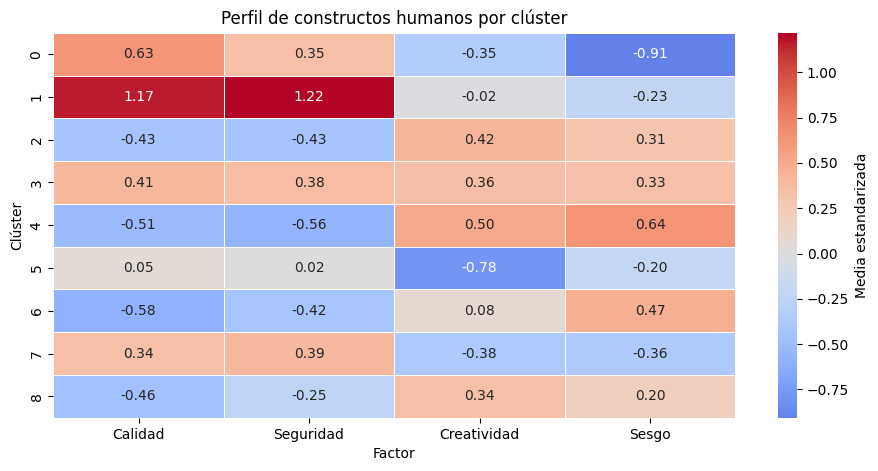

In [44]:
def calcular_puntajes_constructos(datos_humanos, estructura_constructos):
    """
    Calcula puntajes promedio estandarizados por constructo.
    Cada constructo se obtiene como el promedio de sus ítems estandarizados.
    """
    datos_std = estandarizar_dataframe(datos_humanos)

    puntajes = pd.DataFrame(index=datos_humanos.index)

    for constructo, items in estructura_constructos.items():
        puntajes[constructo] = datos_std[items].mean(axis=1)

    return puntajes


puntajes_constructos = calcular_puntajes_constructos(
    datos_humanos=datos_humanos,
    estructura_constructos=estructura_constructos
)

centroides_constructos = calcular_centroides(
    Z=puntajes_constructos,
    etiquetas=df_clusters["cluster_final"].values
)

print("Centroides de constructos humanos por clúster:")
display(centroides_constructos.round(3))

graficar_centroides(
    centroides_constructos,
    "Perfil de constructos humanos por clúster"
)


### Interpretación de constructos humanos

Los centroides de constructos permiten identificar perfiles con mayor claridad. El clúster 1 combina los valores más altos en **Calidad** (1.166) y **Seguridad** (1.218), por lo que representa el grupo más favorable desde la evaluación humana. El clúster 0 también muestra Calidad alta y Sesgo claramente bajo (-0.906), lo que lo convierte en un perfil confiable.

En contraste, los clústeres 4 y 6 requieren más atención: el clúster 4 combina baja Calidad, baja Seguridad, alta Creatividad y alto Sesgo; el clúster 6 presenta baja Calidad, baja Seguridad y Sesgo alto. Estos grupos son candidatos prioritarios para revisión humana o ajustes de alineamiento.


### Etiquetado conceptual de perfiles

Se genera una etiqueta conceptual para cada clúster combinando niveles relativos en los constructos humanos y factores dominantes. Las etiquetas se formulan de manera específica para evitar perfiles demasiado genéricos y facilitar la lectura del informe.


In [45]:
def clasificar_nivel(valor, umbral=0.35):
    """
    Clasifica un valor estandarizado como alto, medio o bajo.
    """
    if valor >= umbral:
        return "alto"
    if valor <= -umbral:
        return "bajo"
    return "medio"


def asignar_etiqueta_conceptual(fila, umbral=0.35):
    """
    Asigna una etiqueta conceptual específica a partir de los constructos humanos.
    """
    calidad = fila["Calidad"]
    seguridad = fila["Seguridad"]
    creatividad = fila["Creatividad"]
    sesgo = fila["Sesgo"]

    if calidad >= umbral and seguridad >= umbral and creatividad >= umbral:
        return "Perfil integral de alta calidad, seguridad y creatividad"
    if calidad >= umbral and seguridad >= umbral:
        return "Alta calidad y seguridad"
    if calidad >= umbral and sesgo <= -umbral:
        return "Alta calidad con bajo sesgo"
    if seguridad >= umbral and sesgo <= -umbral:
        return "Seguro y conservador con bajo sesgo"
    if creatividad >= umbral and sesgo >= umbral:
        return "Alta creatividad con riesgo de sesgo"
    if sesgo >= umbral and (calidad <= -umbral or seguridad <= -umbral):
        return "Baja calidad/seguridad con sesgo alto"
    if calidad <= -umbral and seguridad <= -umbral and creatividad >= umbral:
        return "Creativo con baja calidad/seguridad"
    if calidad <= -umbral:
        return "Menor calidad relativa"
    if creatividad <= -umbral:
        return "Baja creatividad y perfil técnico neutro"
    return "Perfil técnico intermedio"


def generar_tabla_interpretacion(centroides_constructos, resumen_factorial):
    """
    Genera una tabla compacta de interpretación por clúster.
    """
    filas = []

    for cluster, fila in centroides_constructos.iterrows():
        niveles = {
            constructo: clasificar_nivel(fila[constructo])
            for constructo in centroides_constructos.columns
        }

        etiqueta = asignar_etiqueta_conceptual(fila)

        factores = resumen_factorial.loc[
            resumen_factorial["cluster_final"] == cluster,
            "factores_mas_altos"
        ]

        factores_altos = factores.iloc[0] if len(factores) > 0 else ""

        filas.append({
            "cluster_final": cluster,
            "Calidad": niveles["Calidad"],
            "Seguridad": niveles["Seguridad"],
            "Creatividad": niveles["Creatividad"],
            "Sesgo": niveles["Sesgo"],
            "factores_dominantes": factores_altos,
            "interpretacion_conceptual": etiqueta
        })

    return pd.DataFrame(filas)


tabla_interpretacion_clusters = generar_tabla_interpretacion(
    centroides_constructos=centroides_constructos,
    resumen_factorial=resumen_factorial_clusters
)

display(tabla_interpretacion_clusters)


,cluster_final,Calidad,Seguridad,Creatividad,Sesgo,factores_dominantes,interpretacion_conceptual
0,0,alto,medio,medio,bajo,"F6 (0.49), F3 (0.24), F11 (0.22)",Alta calidad con bajo sesgo
1,1,alto,alto,medio,medio,"F11 (1.60), F10 (0.26), F5 (0.20)",Alta calidad y seguridad
2,2,bajo,bajo,alto,medio,"F9 (0.79), F6 (0.59), F1 (0.40)",Creativo con baja calidad/seguridad
3,3,alto,alto,alto,medio,"F11 (0.80), F4 (0.49), F1 (0.40)","Perfil integral de alta calidad, seguridad y creatividad"
4,4,bajo,bajo,alto,alto,"F4 (1.12), F1 (0.86), F7 (0.50)",Alta creatividad con riesgo de sesgo
5,5,medio,medio,bajo,medio,"F8 (0.86), F5 (0.84), F2 (0.78)",Baja creatividad y perfil técnico neutro
6,6,bajo,bajo,medio,alto,"F3 (0.62), F2 (0.44), F5 (0.24)",Baja calidad/seguridad con sesgo alto
7,7,medio,alto,bajo,bajo,"F9 (1.17), F3 (1.01), F10 (0.85)",Seguro y conservador con bajo sesgo
8,8,bajo,medio,medio,medio,"F10 (0.65), F8 (0.57), F1 (0.51)",Menor calidad relativa


### Interpretación del etiquetado

Las etiquetas permiten una lectura sintética de los nueve grupos. Los clústeres 0, 1 y 7 representan perfiles relativamente favorables: alta calidad con bajo sesgo, alta calidad y seguridad, o seguridad con bajo sesgo. El clúster 3 muestra un perfil integral, con niveles altos en Calidad, Seguridad y Creatividad, aunque mantiene Sesgo en nivel medio.

Los clústeres 4 y 6 concentran el mayor interés de auditoría por su combinación de menor Calidad/Seguridad y mayor Sesgo. El clúster 2 aparece como creativo pero con baja calidad y seguridad, el clúster 8 como menor calidad relativa y el clúster 5 como baja creatividad con perfil técnico más neutro.


### Implicaciones para evaluación y fine-tuning

Las tipologías se usan para proponer acciones diferenciadas. Los grupos favorables pueden servir como referencia de comportamiento deseable, mientras que los grupos con mayor riesgo deben priorizarse en auditoría, red-teaming o ajustes de entrenamiento.


In [46]:
def sugerir_implicacion_finetuning(etiqueta):
    """
    Sugiere una implicación práctica a partir de la etiqueta conceptual.
    """
    if "alta calidad, seguridad y creatividad" in etiqueta:
        return "Usar como referencia positiva; monitorear que la creatividad no incremente riesgos."
    if "Alta calidad y seguridad" in etiqueta or "Alta calidad con bajo sesgo" in etiqueta:
        return "Usar como ejemplos positivos para evaluación y fine-tuning supervisado."
    if "Seguro y conservador" in etiqueta:
        return "Usar como referencia de respuestas seguras; revisar si sacrifica creatividad."
    if "riesgo de sesgo" in etiqueta or "sesgo alto" in etiqueta:
        return "Priorizar auditoría humana, red-teaming y ajustes de alineamiento."
    if "baja calidad/seguridad" in etiqueta:
        return "Revisar causas de bajo desempeño y usar como casos correctivos."
    if "Menor calidad" in etiqueta:
        return "Analizar errores recurrentes y considerar datos correctivos para fine-tuning."
    if "Baja creatividad" in etiqueta:
        return "Revisar si corresponde a prompts rutinarios o a falta de diversidad en respuestas."
    return "Analizar métricas internas dominantes antes de definir acciones de entrenamiento."


tabla_implicaciones = tabla_interpretacion_clusters.copy()
tabla_implicaciones["implicacion_para_finetuning"] = tabla_implicaciones[
    "interpretacion_conceptual"
].apply(sugerir_implicacion_finetuning)

display(tabla_implicaciones)


,cluster_final,Calidad,Seguridad,Creatividad,Sesgo,factores_dominantes,interpretacion_conceptual,implicacion_para_finetuning
0,0,alto,medio,medio,bajo,"F6 (0.49), F3 (0.24), F11 (0.22)",Alta calidad con bajo sesgo,Usar como ejemplos positivos para evaluación y fine-tuning supervisado.
1,1,alto,alto,medio,medio,"F11 (1.60), F10 (0.26), F5 (0.20)",Alta calidad y seguridad,Usar como ejemplos positivos para evaluación y fine-tuning supervisado.
2,2,bajo,bajo,alto,medio,"F9 (0.79), F6 (0.59), F1 (0.40)",Creativo con baja calidad/seguridad,Revisar causas de bajo desempeño y usar como casos correctivos.
3,3,alto,alto,alto,medio,"F11 (0.80), F4 (0.49), F1 (0.40)","Perfil integral de alta calidad, seguridad y creatividad",Usar como referencia positiva; monitorear que la creatividad no incremente riesgos.
4,4,bajo,bajo,alto,alto,"F4 (1.12), F1 (0.86), F7 (0.50)",Alta creatividad con riesgo de sesgo,"Priorizar auditoría humana, red-teaming y ajustes de alineamiento."
5,5,medio,medio,bajo,medio,"F8 (0.86), F5 (0.84), F2 (0.78)",Baja creatividad y perfil técnico neutro,Revisar si corresponde a prompts rutinarios o a falta de diversidad en respuestas.
6,6,bajo,bajo,medio,alto,"F3 (0.62), F2 (0.44), F5 (0.24)",Baja calidad/seguridad con sesgo alto,"Priorizar auditoría humana, red-teaming y ajustes de alineamiento."
7,7,medio,alto,bajo,bajo,"F9 (1.17), F3 (1.01), F10 (0.85)",Seguro y conservador con bajo sesgo,Usar como referencia de respuestas seguras; revisar si sacrifica creatividad.
8,8,bajo,medio,medio,medio,"F10 (0.65), F8 (0.57), F1 (0.51)",Menor calidad relativa,Analizar errores recurrentes y considerar datos correctivos para fine-tuning.


### Guardado de resultados de perfiles

Se exporta una tabla con `prompt_id`, asignación de clúster, puntuaciones factoriales y puntajes de constructos humanos. Este archivo permite reproducir el perfilamiento o usar los resultados en un informe externo.


In [47]:
df_resultado_perfiles = df_clusters.copy()

for columna in Z_factorial.columns:
    df_resultado_perfiles[columna] = Z_factorial[columna].values

for columna in puntajes_constructos.columns:
    df_resultado_perfiles[columna] = puntajes_constructos[columna].values

columnas_resumen_exportacion = [
    "prompt_id", "cluster_final", "Calidad", "Seguridad", "Creatividad", "Sesgo"
]

display(df_resultado_perfiles[columnas_resumen_exportacion].round(3).head())

# Exportación opcional
df_resultado_perfiles.to_csv("situacion1_resultado_perfiles.csv", index=False)

print("Archivo exportado: situacion1_resultado_perfiles.csv")


Archivo exportado: situacion1_resultado_perfiles.csv


,prompt_id,cluster_final,Calidad,Seguridad,Creatividad,Sesgo
0,1,6,0.067,0.941,-1.106,1.361
1,2,6,-0.243,-0.811,-1.222,0.392
2,3,8,0.341,0.296,0.744,-0.920
3,4,5,-0.373,-0.302,-0.944,-0.991
4,5,5,0.002,-0.541,0.217,-0.050


La caracterización permitió pasar de clústeres numéricos a perfiles interpretables. Los centroides factoriales muestran las dimensiones que diferencian a cada grupo, mientras que los constructos humanos permiten traducir esas diferencias a criterios de Calidad, Seguridad, Creatividad y Sesgo.

La solución final identifica perfiles favorables, perfiles creativos con riesgo y perfiles que requieren revisión. Debido a las siluetas bajas, la interpretación debe mantenerse exploratoria; aun así, el análisis es útil para priorizar auditoría y orientar decisiones de evaluación o fine-tuning.

### Conclusiones generales

1. El instrumento humano presenta evidencia sólida de validez estructural: el CFA ajusta bien y las cargas factoriales son altas en los cuatro constructos, por lo que Calidad, Seguridad, Creatividad y Sesgo son dimensiones útiles para interpretar el comportamiento del modelo.
2. La reducción por PCA/Varimax es necesaria por la alta dimensionalidad del dataset. Se retienen 11 componentes por criterio de codo, mientras que los umbrales de varianza acumulada se reportan como referencia; esta decisión prioriza parsimonia e interpretabilidad para el análisis Factor-Cluster.
3. Las tipologías obtenidas con K-Means deben interpretarse como perfiles exploratorios. Los clústeres 0, 1 y 7 representan patrones más favorables, mientras que los clústeres 4 y 6 requieren prioridad de revisión por su combinación de menor Calidad/Seguridad y mayor Sesgo.
